# Imports

In [36]:
import pandas as pd
import numpy as np


from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler



from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn import neighbors
from xgboost import XGBClassifier, plot_importance
import pickle
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline




In [52]:
#importing data 

#df with dummy categorical variables, no missing data
dummy_df = pd.read_csv("../data/processed/dummy_df_no_missing.csv")
#df with dummy categorical variables, missing data in contact column
dummy_full_contact_df = pd.read_csv("../data/processed/dummy_df_with_contact.csv")
#df with encoded categorical variables, no missing data
encoded_df = pd.read_csv("../data/processed/encoded_df_no_missing.csv")
#df with encoded categorical variables, missing data in contact column
encoded_full_contact_df = pd.read_csv("../data/processed/encoded_df_with_contact.csv")

engineered_df = pd.read_csv("../data/processed/engineered_df.csv")


engineered_full_contact_df = pd.read_csv("../data/processed/engineered_df_with_contact.csv")



In [53]:
datasets = {
    "encoded_with_contact": encoded_full_contact_df,
    "encoded": encoded_df,
    "dummy_with_contact": dummy_full_contact_df,
    "dummy": dummy_df,
    "engineered": engineered_df,
    "engineered_with_contact": engineered_full_contact_df
}

In [39]:
encoded_full_contact_df.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,duration,campaign,y,month_sin,month_cos
count,38469.000000,38469.000000,38469.000000,38469.000000,38469.000000,38469.000000,38469.000000,38469.000000,38469.000000,38469.000000,38469.000000,38469.000000,38469.000000,3.846900e+04,38469.000000
mean,40.403624,4.259300,1.153578,1.128311,0.020198,1267.535288,0.604305,0.176844,0.686189,16.012686,254.981726,2.875848,0.072786,5.672233e-02,-0.512701
std,9.593403,3.276512,0.606854,0.661691,0.140679,2890.878338,0.489006,0.381541,0.918902,8.261939,259.678378,3.200970,0.259788,5.939143e-01,0.617418
min,19.000000,0.000000,0.000000,0.000000,0.000000,-8019.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,-8.660254e-01,-1.000000
25%,33.000000,1.000000,1.000000,1.000000,0.000000,54.000000,0.000000,0.000000,0.000000,8.000000,100.000000,1.000000,0.000000,-5.000000e-01,-0.866025
50%,39.000000,4.000000,1.000000,1.000000,0.000000,403.000000,1.000000,0.000000,0.000000,17.000000,175.000000,2.000000,0.000000,1.224647e-16,-0.866025
75%,48.000000,7.000000,2.000000,2.000000,0.000000,1314.000000,1.000000,0.000000,2.000000,21.000000,313.000000,3.000000,0.000000,5.000000e-01,-0.500000
max,95.000000,11.000000,2.000000,2.000000,1.000000,102127.000000,1.000000,1.000000,2.000000,31.000000,4918.000000,58.000000,1.000000,1.000000e+00,1.000000


# Train/Test Split

In [94]:
def prepare_data(df):
    # Separate features and target
    X = df.drop(columns='y')
    y = df["y"]

    #Create training and testing datasets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    # Synthetic Minority Over-sampling Technique (SMOTE)
    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

    # Random undersampler
    rus = RandomUnderSampler(random_state=42)
    X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_train_sm": X_train_sm,
        "y_train_sm": y_train_sm,
        "X_train_rus": X_train_rus,
        "y_train_rus": y_train_rus,
    }

In [76]:
results = {}
for name, df in datasets.items():
    results[name] = prepare_data(df)

# Stage 1: Cheap Model Comparison

In [42]:
# Finding F1 with logistic regression
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = LogisticRegression(random_state=42, max_iter=2000)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = LogisticRegression(random_state=42, max_iter=2000)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))


                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.179618  0.180472
1                  encoded  0.204328  0.206355
2       dummy_with_contact  0.204860  0.209068
3                    dummy  0.221178  0.231334
4               engineered  0.207106  0.208036
5  engineered_with_contact  0.173624  0.178820


In [43]:
# Finding F1 with random forest classifier
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = RandomForestClassifier(n_estimators=100,random_state=42)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = RandomForestClassifier(n_estimators=100,random_state=42)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))


                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.206825  0.188940
1                  encoded  0.250597  0.227987
2       dummy_with_contact  0.184049  0.185497
3                    dummy  0.222738  0.229894
4               engineered  0.226322  0.222222
5  engineered_with_contact  0.173724  0.190217


In [44]:
# Finding F1 with deicison tree classifier
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = DecisionTreeClassifier(random_state=42)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = DecisionTreeClassifier(random_state=42)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))


                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.186131  0.160000
1                  encoded  0.198537  0.202835
2       dummy_with_contact  0.175115  0.169619
3                    dummy  0.188679  0.208999
4               engineered  0.192179  0.197751
5  engineered_with_contact  0.160813  0.164360


## XGBoost

In [45]:
# Finding F1 with XGBoost
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = XGBClassifier(random_state=42)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = XGBClassifier(random_state=42)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))


                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.229333  0.199327
1                  encoded  0.248571  0.240064
2       dummy_with_contact  0.235609  0.203199
3                    dummy  0.260234  0.247846
4               engineered  0.264840  0.237970
5  engineered_with_contact  0.205607  0.209108


In [46]:
# Finding F1 with SVM
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = svm.SVC(random_state=42)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = svm.SVC(random_state=42)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))


KeyboardInterrupt: 

In [ ]:
# Finding F1 with KNN
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = neighbors.KNeighborsClassifier()
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = neighbors.KNeighborsClassifier()
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))


                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.473220  0.446154
1                  encoded  0.477926  0.447018
2       dummy_with_contact  0.454435  0.400182
3                    dummy  0.449128  0.410526
4               engineered  0.497059  0.483333
5  engineered_with_contact  0.489362  0.454856


After the preliminary tests, on all four datasets and two sampling models:
* Removing the missing data from the contact column (although it is a larger portion, seems to give more accurate results)
* Using the under sampling method tends to be better than using the oversampling method
* Our top performing models are XGBoost and Random Forest Classifier

# Feature Selection (ANOVA F-test)

In [95]:
#getting engineered data 
data = results['engineered']


print(data['X_test'].shape)
print(data['X_train_sm'].shape)


(5259, 20)
(38368, 20)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

def select_features(X, y, k=10):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X, y)

    f_scores = pd.DataFrame({
        'feature': X.columns,
        'f_score': selector.scores_,
        'p_value': selector.pvalues_
    }).sort_values('f_score', ascending=False).reset_index(drop=True)

    selected_features = list(X.columns[selector.get_support()])
    return f_scores, selected_features


f_scores, selected_features = select_features(data['X_train'], data['y_train'], k='all')
print(f_scores)

             feature      f_score       p_value
0           duration  5648.905272  0.000000e+00
1          long_call  5110.790117  0.000000e+00
2       duration_log  3204.157359  0.000000e+00
3              march   445.217776  8.172820e-98
4            quarter   158.023735  4.124121e-36
5             season    76.785636  2.047272e-18
6           campaign    55.160459  1.153141e-13
7            housing    52.234414  5.093868e-13
8               loan    39.715078  2.996814e-10
9          education    39.705002  3.012285e-10
10           marital    33.199905  8.431562e-09
11           balance    29.546404  5.520094e-08
12  campaign_squared    24.108977  9.171723e-07
13     many_contacts    19.493919  1.014231e-05
14               day     9.180202  2.449441e-03
15           contact     6.330265  1.187684e-02
16               age     4.947460  2.613960e-02
17           default     3.835582  5.018876e-02
18               job     2.757597  9.680843e-02
19             month     1.759825  1.846

In [ ]:
print(f_scores.feature.head(10).tolist())


['duration', 'long_call', 'duration_log', 'march', 'quarter', 'season', 'campaign', 'housing', 'loan', 'education']


## XGBoost

In [79]:
#Using XGBoost's native class-imbalance handling (scale_pos_weight) instead of
#SMOTE: it avoids synthetic-sample leakage across CV folds and tested higher
#on 5-fold CV F1 (see experiment: scale_pos_weight ~0.345 vs SMOTE ~0.283).
neg, pos = (data['y_train'] == 0).sum(), (data['y_train'] == 1).sum()
scale_pos_weight = neg / pos

pipeline = Pipeline([
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        scale_pos_weight=scale_pos_weight,
    ))
])

In [84]:
param_grid = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__learning_rate': [0.01, 0.1, 0.3],
    'classifier__n_estimators': [50, 100, 200]
}

#average_precision (PR-AUC) is threshold-independent, so hyperparameter
#selection isn't distorted by the default 0.5 cutoff. The decision threshold
#is tuned separately below, after the best model is chosen.
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='average_precision')
x_data = data['X_train'][['duration', 'long_call', 'month', 'march', 'housing', 'season', 'quarter', 'education', 'loan', 'contact']]
grid_search.fit(x_data, data['y_train'])

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV average precision: {grid_search.best_score_}")

Best parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.3, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 50, 'classifier__subsample': 1.0}
Best CV average precision: 0.5462611678582745


In [88]:
#Pick the F1-optimal decision threshold using out-of-fold predictions on the
#training set only (5-fold CV), so the held-out test set stays untouched
#until final evaluation.
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

oof_probs = cross_val_predict(
    grid_search.best_estimator_, data['X_train'], data['y_train'],
    cv=5, method='predict_proba', n_jobs=-1
)[:, 1]


prec, rec, thresholds = precision_recall_curve(data['y_train'], oof_probs)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print(f"Best threshold (out-of-fold): {best_threshold:.4f}")
print(f"Out-of-fold F1 at this threshold: {f1_scores[:-1].max():.4f}")

Best threshold (out-of-fold): 0.7576
Out-of-fold F1 at this threshold: 0.5902


In [89]:
with open('../models/xgb_model.pkl', 'wb') as file:
    pickle.dump({'model': grid_search.best_estimator_, 'threshold': best_threshold}, file)

In [92]:
with open('../models/xgb_model.pkl', 'rb') as file:
    saved = pickle.load(file)

model = saved['model']
threshold = saved['threshold']

x_test = data['X_test'][['duration', 'long_call', 'month', 'march', 'housing', 'season', 'quarter', 'education', 'loan', 'contact']]

probs_test = model.predict_proba(x_test)[:, 1]
y_pred = (probs_test >= threshold).astype(int)
score = f1_score(data["y_test"], y_pred)
print(f"Test F1 (tuned threshold={threshold:.4f}): {score:.4f}")

Test F1 (tuned threshold=0.7576): 0.5892


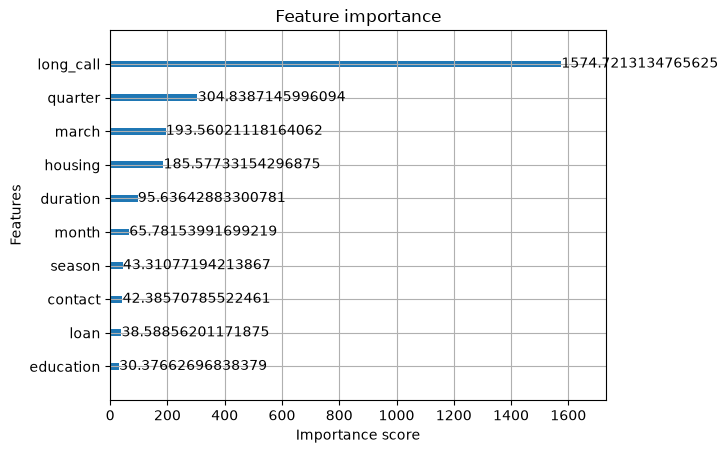

In [93]:
plot_importance(model.named_steps['classifier'], importance_type="gain")
plt.show()

In [ ]:
"""feature_names = X.columns
coefficients = model.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Importance': np.abs(coefficients)
})

importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False).reset_index(drop=True)
print(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Abs_Importance'], color='skyblue')
plt.xlabel('Feature Importance (Absolute Coefficient)')
plt.ylabel('Features')
plt.title('Logistic Regression Feature Importance')
plt.gca().invert_yaxis()  # Put highest importance on top
plt.show()"""

"feature_names = X.columns\ncoefficients = model.coef_[0]\n\nimportance_df = pd.DataFrame({\n    'Feature': feature_names,\n    'Coefficient': coefficients,\n    'Abs_Importance': np.abs(coefficients)\n})\n\nimportance_df = importance_df.sort_values(by='Abs_Importance', ascending=False).reset_index(drop=True)\nprint(importance_df)\n\nplt.figure(figsize=(8, 5))\nplt.barh(importance_df['Feature'], importance_df['Abs_Importance'], color='skyblue')\nplt.xlabel('Feature Importance (Absolute Coefficient)')\nplt.ylabel('Features')\nplt.title('Logistic Regression Feature Importance')\nplt.gca().invert_yaxis()  # Put highest importance on top\nplt.show()"